In [1]:
#The code in this block comes directly from data_sort_and_split.ipynb instead sclaing is uneccesary as it is not required for Decision Tree Models
import pandas as pd
from sklearn.model_selection import train_test_split

heart_data = pd.read_csv("heart.csv")

heart_data['Sex_F'] = heart_data['Sex'].map({'M': 0, 'F': 1})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N': 0, 'Y': 1})
heart_data = heart_data.drop(columns=['Sex'])

heart_data['ChestPainType'] = pd.Categorical(heart_data['ChestPainType'], categories=['ASY', 'ATA', 'NAP', 'TA'])
heart_data['RestingECG'] = pd.Categorical(heart_data['RestingECG'], categories=['Normal', 'LVH', 'ST'])
heart_data['ST_Slope'] = pd.Categorical(heart_data['ST_Slope'], categories=['Up', 'Flat', 'Down'])

categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True, dtype=int)

feature_matrix = heart_data.drop("HeartDisease", axis=1)
target_labels = heart_data["HeartDisease"]

features_train, features_test, targets_train, targets_test = train_test_split(
    feature_matrix,
    target_labels,
    test_size=0.20,
    random_state=42,
    stratify= target_labels
)

In [3]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_classifier = DecisionTreeClassifier(
    criterion='entropy',
    min_impurity_decrease=0.01,
    min_samples_split=2,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
#Why: we use entopy as our criterion because it measures the differences in the data at each split which allows it to choose the most informative question about the patient that would further branch it off assisting us on making insights
#Why maxdepth at 5? We chose our tree depth to max at 5 as this would prevent overfitting preventing the model to be too fixated on the components of the training data
#Why min impurity at 0.01? We set this exact number to help make meaningful splits that would further reduce the entropy making the model
#Why min sample split=2? We set it equal to two so each nod could have a minimum of two patients before further spliting
#Why: We set class_weight='balanced' so the model pays extra attention to heart disease patients,since our dataset may have more healthy patients than sick ones.
decision_tree_classifier.fit(features_train, targets_train)
# Why: We train the model on 80% of the patients so it can learn patterns without ever seeing the test set
predicted_labels = decision_tree_classifier.predict(features_test)
#Why: We test the model on the remaining 20% of patients it has never seen before, giving us an honest measure of real-world performance.


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Why: predict_proba gives us the probability of heart disease for each patient rather than
# a hard 0 or 1, which is needed to calculate the ROC-AUC score.
# Why: We take [:, 1] to get only the probability of the positive class (heart disease).
predicted_proba = decision_tree_classifier.predict_proba(features_test)[:, 1]

# Why: We report multiple metrics because accuracy alone is not enough for medical classification.
accuracy  = accuracy_score(targets_test, predicted_labels)
precision = precision_score(targets_test, predicted_labels)
recall    = recall_score(targets_test, predicted_labels)
f1        = f1_score(targets_test, predicted_labels)

# Why: ROC-AUC uses probabilities to measure how well the model separates heart disease
# patients from healthy ones across all possible classification thresholds.
roc_auc   = roc_auc_score(targets_test, predicted_proba)

print("Decision Tree Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

Decision Tree Model Performance:
  Accuracy:  0.8478
  Precision: 0.8776
  Recall:    0.8431
  F1-Score:  0.8600
  ROC-AUC:   0.8842


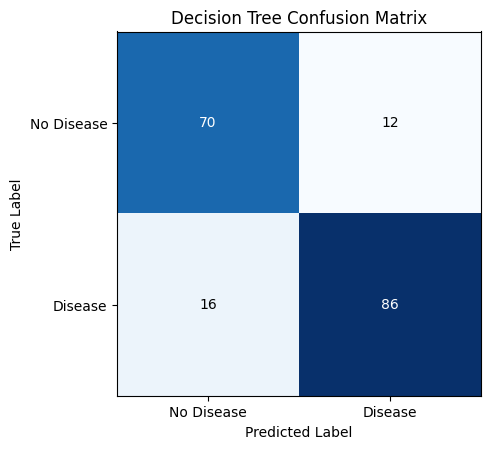

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Why: We generate a standard confusion matrix array to identify True/False Positives and Negatives.
cm = confusion_matrix(targets_test, predicted_labels)

# Why: figsize=(5,5) and the 2x2 nature of the data naturally create a square appearance.
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Why: Adding labels to the axes makes the matrix readable for medical professionals.
classes = ['No Disease', 'Disease']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Why: We loop through the matrix to place the actual counts in the center of each square.
# Why: The color 'white' or 'black' is chosen based on the background darkness for contrast.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

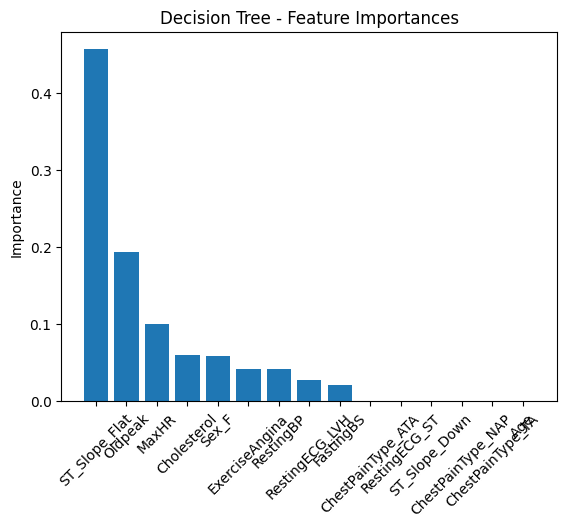

In [7]:
import numpy as np

# Why: Feature importances show which patient symptoms the model relied on most,
# adding medical interpretability to our predictions.
feature_names = features_train.columns
importances = decision_tree_classifier.feature_importances_
indices = np.argsort(importances)[::-1]

plt.bar(x=[feature_names[i] for i in indices], height=importances[indices])
plt.title('Decision Tree - Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()